## Извлечение тегов из отзывов

Ноутбук `extract_tags.ipynb` — извлечение ключевых тегов из текстов отзывов отелей.

In [ ]:
import json
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import spacy

In [ ]:
rows = []

with open('review.txt', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f, start=1):
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f'❌ строка {i} пропущена: {e}')

df = pd.DataFrame(rows)
df.shape


❌ строка 267971 пропущена: Unterminated string starting at: line 1 column 222 (char 221)


(267970, 10)

In [ ]:
rows = []

with open('offering.txt', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f, start=1):
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f'❌ строка {i} пропущена: {e}')

df_offering = pd.DataFrame(rows)
df_offering.shape


(4333, 9)

In [ ]:
df_offering.head()

,hotel_class,region_id,url,phone,details,address,type,id,name
0,4.0,60763,http://www.tripadvisor.com/Hotel_Review-g60763...,,None,"{'region': 'NY', 'street-address': '147 West 4...",hotel,113317,Casablanca Hotel Times Square
1,5.0,32655,http://www.tripadvisor.com/Hotel_Review-g32655...,,None,"{'region': 'CA', 'street-address': '300 S Dohe...",hotel,76049,Four Seasons Hotel Los Angeles at Beverly Hills
2,3.5,60763,http://www.tripadvisor.com/Hotel_Review-g60763...,,None,"{'region': 'NY', 'street-address': '790 Eighth...",hotel,99352,Hilton Garden Inn Times Square
3,4.0,60763,http://www.tripadvisor.com/Hotel_Review-g60763...,,None,"{'region': 'NY', 'street-address': '152 West 5...",hotel,93589,The Michelangelo Hotel
4,4.0,60763,http://www.tripadvisor.com/Hotel_Review-g60763...,,None,"{'region': 'NY', 'street-address': '130 West 4...",hotel,217616,The Muse Hotel New York


In [ ]:
df.head()

In [ ]:
stats = (
    df
    .groupby('offering_id')
    .size()
    .reset_index(name='reviews_count')
)

stats


,offering_id,reviews_count
0,73445,10
1,73463,16
2,73470,29
3,73481,7
4,75688,783
...,...,...
783,3393901,1
784,3502291,2
785,3506933,3
786,3541823,7


In [ ]:
top_100 = stats.sort_values(by='reviews_count', ascending=False).head(100)
top_100


,offering_id,reviews_count
333,214197,5456
80,93520,4009
304,122005,3726
111,93618,3534
356,223023,3385
...,...,...
180,99281,816
72,93470,814
353,223019,814
322,142114,811


In [ ]:
df_offering[df_offering["id"] == 93618]

,hotel_class,region_id,url,phone,details,address,type,id,name
710,4.5,60763,http://www.tripadvisor.com/Hotel_Review-g60763...,,None,"{'region': 'NY', 'street-address': '301 Park A...",hotel,93618,Waldorf Astoria New York


In [ ]:
# BEST WESTERN PLUS Seaport Inn Downtown hotel

hotel_df = df[df["offering_id"] == 93618].reset_index(drop=True)[:300]
hotel_df.head()

,ratings,title,text,author,date_stayed,offering_id,num_helpful_votes,date,id,via_mobile
0,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“Excellent Diamond Reception area”,I just wanted to share that Mary in the Diamon...,"{'username': 'Michele S', 'num_reviews': 1, 'i...",December 2012,93618,0,"December 18, 2012",147689110,False
1,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“A grand old place”,The lobby is superb & the staff are very helpf...,"{'username': 'Lynn S', 'num_cities': 8, 'num_h...",December 2012,93618,0,"December 18, 2012",147682503,False
2,{'overall': 1.0},“Worst experience of all my travels”,I have stayed in top class hotels and shabby b...,"{'username': 'Harry H', 'num_cities': 15, 'num...",December 2012,93618,0,"December 18, 2012",147680483,True
3,"{'service': 4.0, 'cleanliness': 5.0, 'overall'...","“""The Grand Old Lady""”",We were upgraded to a superior double on the 2...,"{'username': 'DarlingHarb0ur', 'num_cities': 1...",December 2012,93618,0,"December 18, 2012",147668766,False
4,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“Most Beautiful Hotel”,Best overall experience I have had at any hote...,"{'username': 'Goose007', 'num_cities': 13, 'nu...",December 2012,93618,0,"December 18, 2012",147665137,False


In [ ]:
import re

def preprocess_text(text):
    text = text.lower()
    # Удаление спецсимволов, но сохранение важных слов
    text = re.sub(r'[^\w\s]', ' ', text)
    return text

hotel_df['clean_text'] = hotel_df['text'].apply(preprocess_text)

In [ ]:
hotel_df

,ratings,title,text,author,date_stayed,offering_id,num_helpful_votes,date,id,via_mobile,clean_text
0,"{'cleanliness': 4.0, 'sleep_quality': 4.0, 'ov...",“South Street Sea Poor”,"Yes, thats right, I dont normally post photos ...","{'username': 'speedotorpedo', 'num_cities': 39...",June 2012,75698,0,"November 26, 2012",146203811,False,yes thats right i dont normally post photos ...
1,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“Perfect location to stay in NYC”,Thank you to all the friendly and helpful staf...,"{'username': 'AnnetteOLeary', 'num_reviews': 1...",October 2012,75698,1,"October 28, 2012",143954226,False,thank you to all the friendly and helpful staf...
2,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“Fabulous place to stay in NYC!”,Where do I start? We arrived at 9 am after cal...,"{'username': 'vagabondmom1', 'num_cities': 50,...",October 2012,75698,1,"October 25, 2012",143736702,False,where do i start we arrived at 9 am after cal...
3,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“Another excellent stay at the Seaport Inn”,Whenever we go to NYC we stay at the Best West...,"{'username': 'trishtraffic', 'num_cities': 5, ...",October 2012,75698,1,"October 25, 2012",143694500,False,whenever we go to nyc we stay at the best west...
4,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“OMG!! This place is the BEST!!!”,I was there for my eldest sons wedding. We arr...,"{'username': 'Sbap19', 'num_reviews': 1, 'id':...",October 2012,75698,1,"October 25, 2012",143690787,False,i was there for my eldest sons wedding we arr...
...,...,...,...,...,...,...,...,...,...,...,...
244,"{'service': 4.0, 'cleanliness': 3.0, 'overall'...",“Zentrales Hotel mit Charme”,Sehr zentrale Lage und komfortable Zimmer zum ...,"{'username': 'DarmstadtBaseball09', 'num_citie...",June 2008,75698,0,"October 11, 2009",46514218,False,sehr zentrale lage und komfortable zimmer zum ...
245,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...","“Deception, Aucune Vue Sur Brooklyn Bridge”","L""hotel est bien. Il est bien situe, dans Sout...","{'username': 'DonPedro93', 'num_cities': 8, 'n...",September 2009,75698,0,"September 10, 2009",40553762,False,l hotel est bien il est bien situe dans sout...
246,"{'service': 4.0, 'cleanliness': 3.0, 'overall'...",“NY_Greith”,"ottima posizione, ottima accoglienza, ci ritor...","{'username': 'Magellanox', 'num_cities': 14, '...",December 2008,75698,0,"August 23, 2009",38552862,False,ottima posizione ottima accoglienza ci ritor...
247,"{'cleanliness': 3.0, 'overall': 4.0, 'location...",“Il fascino della Lower Manhattan”,South Street Seaport per me una delle zone più...,"{'username': 'NewYorkRobe66', 'num_reviews': 1...",September 2008,75698,0,"July 22, 2009",35487938,False,south street seaport per me una delle zone più...


In [ ]:
import spacy
from spacy.matcher import Matcher

nlp = spacy.load("en_core_web_sm")

# Определение аспектов (категорий)
ASPECT_KEYWORDS = {
    'service': ['service', 'staff', 'helpful', 'friendly', 'reception', 'check-in'],
    'cleanliness': ['clean', 'cleanliness', 'tidy', 'spotless', 'dirty'],
    'location': ['location', 'convenient', 'nearby', 'close', 'walk', 'metro'],
    'room': ['room', 'bed', 'bathroom', 'shower', 'space', 'comfortable'],
    'food': ['breakfast', 'restaurant', 'food', 'dining', 'meal', 'delicious'],
    'value': ['price', 'value', 'expensive', 'affordable', 'worth'],
    'amenities': ['wifi', 'parking', 'pool', 'gym', 'facilities']
}

def extract_aspects(text):
    doc = nlp(text)
    found_aspects = []

    for aspect, keywords in ASPECT_KEYWORDS.items():
        for keyword in keywords:
            if keyword in text.lower():
                found_aspects.append(aspect)
                break

    return list(set(found_aspects))

hotel_df['aspects'] = hotel_df['clean_text'].apply(extract_aspects)[:300]

KeyboardInterrupt: 

In [ ]:
from transformers import pipeline

# Используем zero-shot classification
classifier = pipeline("zero-shot-classification",
                     model="facebook/bart-large-mnli")

candidate_labels = [
    "excellent service",
    "clean rooms",
    "great location",
    "delicious food",
    "comfortable beds",
    "good value",
    "friendly staff"
]

def classify_review(text):
    result = classifier(text[:512], candidate_labels)  # ограничение по длине
    # Возвращаем теги с уверенностью > 0.5
    tags = [label for label, score in zip(result['labels'], result['scores'])
            if score > 0.5]
    return tags

# Применяем к подвыборке (медленно)
hotel_df['auto_tags'] = hotel_df['text'].head(100).apply(classify_review)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


KeyboardInterrupt: 

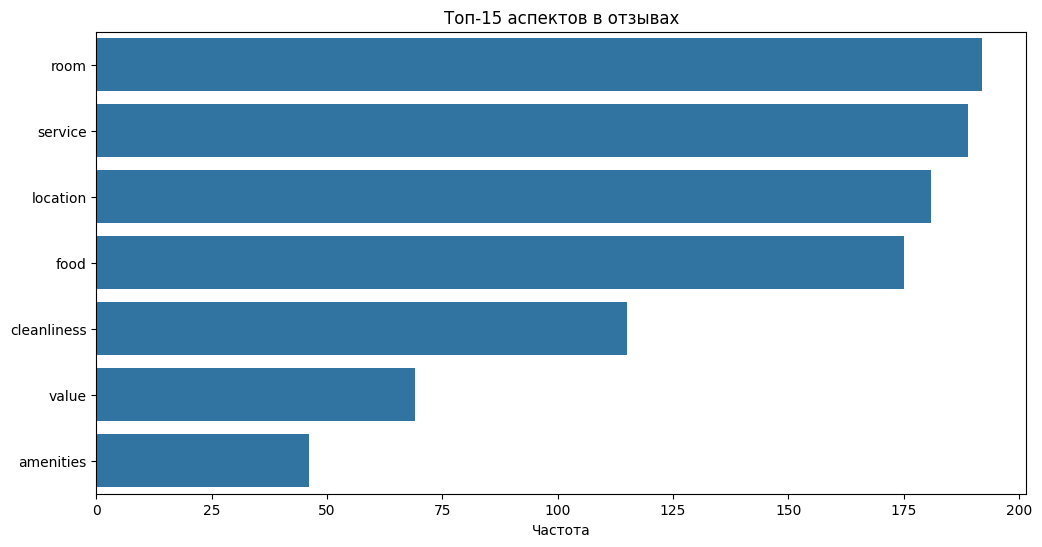

KeyError: 'aspects'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Подсчет частоты тегов
from collections import Counter

all_tags = []
for tags in hotel_df['aspects']:
    all_tags.extend(tags)

tag_counts = Counter(all_tags)

# Визуализация
plt.figure(figsize=(12, 6))
tags, counts = zip(*tag_counts.most_common(15))
sns.barplot(x=list(counts), y=list(tags))
plt.title('Топ-15 аспектов в отзывах')
plt.xlabel('Частота')
plt.show()

# Создание сводной таблицы
summary_df = pd.DataFrame({
    'aspect': list(tag_counts.keys()),
    'count': list(tag_counts.values())
}).sort_values('count', ascending=False)

# Связь с рейтингом
for aspect in ASPECT_KEYWORDS.keys():
    df[f'has_{aspect}'] = df['aspects'].apply(lambda x: aspect in x)
    avg_rating = df[df[f'has_{aspect}']]['ratings'].apply(
        lambda x: x.get('overall', 0) if isinstance(x, dict) else 0
    ).mean()
    print(f"{aspect}: средний рейтинг = {avg_rating:.2f}")

In [ ]:
!pip install keybert keyphrase-vectorizers


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 1.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of spacy-curated-transformers to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.9/237.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.4/313.4 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.4 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import openai
from transformers import pipeline
import re

# 1. ИЗВЛЕЧЕНИЕ КЛЮЧЕВЫХ ФРАЗ ИЗ КАЖДОГО ОТЗЫВА
# ================================================

from keybert import KeyBERT
from keyphrase_vectorizers import KeyphraseCountVectorizer

class ReviewTagExtractor:
    def __init__(self):
        # Модель для извлечения ключевых фраз
        self.kw_model = KeyBERT(model='all-MiniLM-L6-v2')
        # Модель для эмбеддингов
        self.embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

    def extract_key_phrases(self, text, top_n=5):
        """
        Извлекаем ключевые фразы из отзыва
        """
        try:
            # Извлекаем фразы длиной 2-3 слова
            keywords = self.kw_model.extract_keywords(
                text,
                keyphrase_ngram_range=(2, 4),
                stop_words='english',
                top_n=top_n,
                use_mmr=True,  # Максимальное разнообразие
                diversity=0.7
            )
            return [kw[0] for kw in keywords]
        except:
            return []

# Инициализация
extractor = ReviewTagExtractor()

# Применяем к данным
hotel_df['key_phrases'] = hotel_df['text'].apply(
    lambda x: extractor.extract_key_phrases(x, top_n=3)
)

print("Примеры ключевых фраз:")
print(hotel_df[['text', 'key_phrases']].head(3))

Примеры ключевых фраз:
                                                text  \
0  I just wanted to share that Mary in the Diamon...   
1  The lobby is superb & the staff are very helpf...   
2  I have stayed in top class hotels and shabby b...   

                                         key_phrases  
0  [mary diamond reception amazing, staying week ...  
1   [ny staff make hotel, cost ate bull, view noisy]  
2  [motels waldorf astoria, sell upgrade double, ...  


In [ ]:
# 2. КЛАСТЕРИЗАЦИЯ ФРАЗ
# ======================

from collections import Counter

# Собираем все фразы
all_phrases = []
for phrases in hotel_df['key_phrases']:
    all_phrases.extend(phrases)

print(f"Всего извлечено фраз: {len(all_phrases)}")
print(f"Уникальных фраз: {len(set(all_phrases))}")

# Подсчет частоты
phrase_counts = Counter(all_phrases)
print("\nТоп-20 популярных фраз:")
for phrase, count in phrase_counts.most_common(20):
    print(f"{phrase}: {count}")

# Фильтруем редкие фразы (встречаются < 3 раз)
min_frequency = 3
frequent_phrases = [phrase for phrase, count in phrase_counts.items()
                   if count >= min_frequency]

print(f"\nФраз с частотой >= {min_frequency}: {len(frequent_phrases)}")

Всего извлечено фраз: 10602
Уникальных фраз: 10201

Топ-20 популярных фраз:
stayed waldorf astoria: 50
waldorf astoria: 50
stayed waldorf: 20
stay waldorf astoria: 15
stayed waldorf nights: 14
new york: 14
staying waldorf: 13
stay waldorf: 12
bull bear: 9
personal war: 8
waldorf astoria new york: 7
waldorf astoria hotel: 7
staying waldorf astoria: 7
zimmer war: 7
walking distance: 6
sunday brunch: 6
das waldorf astoria ist: 6
chose waldorf astoria: 5
stayed waldorf astoria nights: 5
definitely stay: 5

Фраз с частотой >= 3: 45


In [ ]:
# ====================================
# 3. СЕМАНТИЧЕСКАЯ КЛАСТЕРИЗАЦИЯ ФРАЗ
# ====================================


# Импортируем нужные библиотеки
import hdbscan
import numpy as np

# Получаем эмбеддинги для всех популярных фраз
phrase_embeddings = extractor.embedding_model.encode(
    frequent_phrases,
    show_progress_bar=True
)

# Нормализуем эмбеддинги (для cosine similarity)
phrase_embeddings = phrase_embeddings / np.linalg.norm(
    phrase_embeddings, axis=1, keepdims=True
)

# Кластеризация через HDBSCAN
clusterer = hdbscan.HDBSCAN(
    metric='euclidean',           # косинусная схожесть
    min_cluster_size=2,        # минимальный размер кластера
    cluster_selection_epsilon=0.05,  # точность выделения кластеров
    prediction_data=True
)

cluster_labels = clusterer.fit_predict(phrase_embeddings)

# Группируем фразы по кластерам
clusters = {}
for phrase, label in zip(frequent_phrases, cluster_labels):
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(phrase)

# Выводим кластеры
print("\n" + "="*60)
print("КЛАСТЕРЫ ФРАЗ:")
print("="*60)
for cluster_id, phrases in sorted(clusters.items()):
    if cluster_id == -1:
        print("\n📌 Шум / отдельные фразы (не попали ни в один кластер):")
    else:
        print(f"\n📌 Кластер {cluster_id}:")
    for phrase in phrases[:10]:  # топ-10 фраз в кластере
        count = phrase_counts.get(phrase, '?')  # на случай, если нет в phrase_counts
        print(f"   - {phrase} ({count})")


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


КЛАСТЕРЫ ФРАЗ:

📌 Шум / отдельные фразы (не попали ни в один кластер):
   - hotel room (3)
   - waldorf astoria new york (7)
   - walking distance (6)
   - staff helpful (4)
   - definitely stay (5)
   - wallpaper peeling (3)
   - value money (3)
   - stayed waldorf long weekend (3)
   - new york waldorf astoria (3)
   - stayed nights (4)

📌 Кластер 0:
   - visit new york (4)
   - new york city (3)
   - hotels new york (3)
   - new york (14)
   - hotels ny (3)

📌 Кластер 1:
   - hotel waldorf (3)
   - waldorf astoria hotel (7)
   - waldorf astoria beautiful hotel (3)
   - hotel como el waldorf (3)

📌 Кластер 2:
   - waldorf astoria (50)
   - chose waldorf astoria (5)
   - arrived waldorf astoria (3)
   - das waldorf astoria ist (6)

📌 Кластер 3:
   - stayed waldorf (20)
   - staying waldorf (13)
   - stay waldorf (12)

📌 Кластер 4:
   - stayed waldorf astoria (50)
   - stay waldorf astoria (15)
   - staying waldorf astoria (7)
   - returned stay waldorf astoria (3)
   - stayed waldorf

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# ============================================
# TF-IDF с умной фильтрацией
# ============================================

# Стоп-слова: расширенный список
custom_stop_words = [
    'hotel', 'stayed', 'stay', 'staying', 'visited', 'visit',
    'went', 'arrived', 'left', 'checked', 'night', 'nights',
    'day', 'days', 'time', 'times', 'got', 'said', 'told',
    'asked', 'wanted', 'needed', 'room', 'rooms',  # room слишком общее
    # Названия отелей (добавьте свои)
    'waldorf', 'astoria', 'hilton', 'marriott', 'hyatt'
]

# Создаем TF-IDF векторизатор
tfidf = TfidfVectorizer(
    ngram_range=(2, 4),  # биграммы, триграммы, 4-граммы
    max_features=500,     # топ-500 фраз
    min_df=3,            # фраза должна встречаться минимум в 3 документах
    max_df=0.5,          # но не более чем в 50% документов
    stop_words=list(set(custom_stop_words)),
    token_pattern=r'\b[a-zA-Z]{3,}\b',  # только слова от 3 букв
    lowercase=True
)

# Применяем к отзывам
tfidf_matrix = tfidf.fit_transform(hotel_df['text'])

# Получаем фразы и их важность
feature_names = tfidf.get_feature_names_out()

# Считаем средний TF-IDF для каждой фразы
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# Создаем DataFrame с результатами
phrases_df = pd.DataFrame({
    'phrase': feature_names,
    'tfidf_score': tfidf_scores,
    'doc_frequency': (tfidf_matrix > 0).sum(axis=0).A1  # в скольких документах встречается
})

# Сортируем по важности
phrases_df = phrases_df.sort_values('tfidf_score', ascending=False)

print("="*60)
print("TF-IDF: ТОП-30 ФРАЗ")
print("="*60)
print(phrases_df.head(30).to_string(index=False))

# Дополнительная фильтрация
def is_meaningful_phrase(phrase):
    """
    Проверяем, несет ли фраза смысловую нагрузку
    """
    # Убираем фразы только с прилагательными/наречиями без существительных
    if len(phrase.split()) < 2:
        return False

    # Убираем даты и числа
    if any(char.isdigit() for char in phrase):
        return False

    # Убираем слишком общие слова
    generic_words = ['really', 'very', 'highly', 'definitely', 'absolutely']
    if any(word in phrase for word in generic_words):
        return False

    return True

# Применяем фильтр
meaningful_phrases = phrases_df[
    phrases_df['phrase'].apply(is_meaningful_phrase)
].head(100)

print("\n" + "="*60)
print("ПОСЛЕ ФИЛЬТРАЦИИ: ТОП-30")
print("="*60)
print(meaningful_phrases.head(30).to_string(index=False))

TF-IDF: ТОП-30 ФРАЗ
      phrase  tfidf_score  doc_frequency
     and the     0.051592            123
     for the     0.041236             82
   the lobby     0.040803             82
    new york     0.037112             72
    with the     0.030755             59
    was very     0.029457             59
     the was     0.029334             62
   the staff     0.027656             58
     but the     0.026051             48
     the are     0.024673             29
    from the     0.023964             43
     the and     0.023805             46
     you can     0.022554             33
     and was     0.022265             39
the location     0.022261             38
     all the     0.021751             40
     was the     0.021486             45
    that the     0.021340             42
     did not     0.020861             35
   there was     0.020820             41
     was not     0.019842             31
 the service     0.019576             34
   which was     0.019488            

In [ ]:
import yake

# ============================================
# YAKE - статистический экстрактор
# ============================================

# Настройки YAKE
yake_extractor = yake.KeywordExtractor(
    lan="en",                    # язык
    n=3,                         # максимальная длина n-грамм
    dedupLim=0.7,               # порог дедупликации (0.7 = 70% схожести)
    dedupFunc='seqm',           # метод дедупликации
    windowsSize=1,              # окно контекста
    top=20,                     # топ-20 ключевых фраз из каждого документа
    features=None
)

# Извлекаем ключевые слова из каждого отзыва
all_keywords = []

for idx, text in enumerate(hotel_df['text'][:1000]):  # берем первые 1000 для скорости
    try:
        keywords = yake_extractor.extract_keywords(text)
        # keywords = [(фраза, score), ...] - чем меньше score, тем лучше
        for kw, score in keywords:
            if score < 0.1:  # берем только с хорошим score
                all_keywords.append({
                    'phrase': kw,
                    'score': score,
                    'review_id': idx
                })
    except:
        continue

# Агрегируем результаты
yake_df = pd.DataFrame(all_keywords)

# Группируем одинаковые фразы
yake_summary = yake_df.groupby('phrase').agg({
    'score': 'mean',           # средний score
    'review_id': 'count'       # частота встречаемости
}).rename(columns={'review_id': 'frequency'})

# Сортируем по частоте и качеству
yake_summary['rank_score'] = (
    yake_summary['frequency'] * (1 - yake_summary['score'])
)
yake_summary = yake_summary.sort_values('rank_score', ascending=False)

print("\n" + "="*60)
print("YAKE: ТОП-30 ФРАЗ")
print("="*60)
print(yake_summary.head(30))

# Фильтруем те же условия
yake_filtered = yake_summary[
    yake_summary.index.map(is_meaningful_phrase)
]

print("\n" + "="*60)
print("YAKE ПОСЛЕ ФИЛЬТРАЦИИ: ТОП-30")
print("="*60)
print(yake_filtered.head(30))


YAKE: ТОП-30 ФРАЗ
                          score  frequency  rank_score
phrase                                                
Waldorf                0.067250         86   80.216528
Waldorf Astoria        0.017693         43   42.239185
room                   0.063660         41   38.389925
hotel                  0.067473         40   37.301091
Astoria                0.064355         37   34.618873
NYC                    0.064143         22   20.588860
York                   0.064482         21   19.645885
Grand Central Station  0.037891          8    7.696871
Park Avenue            0.051557          8    7.587546
Hotel                  0.059401          8    7.524792
York City              0.039396          7    6.724228
stay                   0.073313          7    6.486806
Waldorf Towers         0.057590          6    5.654462
Central Station        0.066626          6    5.600244
night                  0.077667          6    5.533998
Art Deco               0.023631          5    

In [ ]:
import spacy
from collections import Counter

# ============================================
# spaCy: извлечение именных групп
# ============================================

# Загружаем модель
nlp = spacy.load("en_core_web_sm")

def extract_noun_chunks(text):
    """
    Извлекаем осмысленные именные группы
    """
    doc = nlp(text[:1000000])  # ограничение по длине для spaCy

    chunks = []
    for chunk in doc.noun_chunks:
        # Фильтруем по части речи корневого слова
        if chunk.root.pos_ in ['NOUN', 'PROPN']:
            # Нормализуем
            chunk_text = chunk.text.lower().strip()

            # Убираем местоимения и артикли в начале
            chunk_text = re.sub(r'^(the|a|an|my|our|your|their)\s+', '', chunk_text)

            # Минимальная длина
            if len(chunk_text.split()) >= 2 and len(chunk_text) > 5:
                chunks.append(chunk_text)

    return chunks

# Применяем к отзывам
print("Извлечение noun chunks...")
all_chunks = []

for text in hotel_df['text'][:1000]:  # первые 1000
    try:
        chunks = extract_noun_chunks(text)
        all_chunks.extend(chunks)
    except:
        continue

# Подсчитываем частоту
chunk_counts = Counter(all_chunks)

# Создаем DataFrame
spacy_df = pd.DataFrame(
    chunk_counts.most_common(200),
    columns=['phrase', 'frequency']
)

print("\n" + "="*60)
print("spaCy NOUN CHUNKS: ТОП-30")
print("="*60)
print(spacy_df.head(30).to_string(index=False))

# Фильтрация
spacy_filtered = spacy_df[
    spacy_df['phrase'].apply(is_meaningful_phrase) &
    (spacy_df['frequency'] >= 3)
]

print("\n" + "="*60)
print("spaCy ПОСЛЕ ФИЛЬТРАЦИИ: ТОП-30")
print("="*60)
print(spacy_filtered.head(30).to_string(index=False))

Извлечение noun chunks...

spaCy NOUN CHUNKS: ТОП-30
               phrase  frequency
           this hotel         68
             new york         62
      waldorf astoria         51
         times square         20
           front desk         19
           this place         18
         room service         18
          park avenue         15
         central park         14
       great location         14
      hurricane sandy         12
        peacock alley         11
             mini bar         10
        new york city         10
               no one          9
grand central station          9
     customer service          8
            one night          8
       waldorf towers          8
     walking distance          8
         public areas          7
           5th avenue          7
        upgraded room          7
         other hotels          7
     waldorf asstoria          7
         another room          7
    chrysler building          7
            free wifi  

In [ ]:
!pip install yake

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 7.6 MB/s eta 0:00:00


In [ ]:
# ============================================
# КОМБИНИРОВАННЫЙ ПОДХОД
# ============================================

# Объединяем результаты всех методов
combined_phrases = set()

# Из TF-IDF
combined_phrases.update(meaningful_phrases['phrase'].head(50).tolist())

# Из YAKE
combined_phrases.update(yake_filtered.head(50).index.tolist())

# Из spaCy
combined_phrases.update(spacy_filtered['phrase'].head(50).tolist())

print(f"\nВсего уникальных фраз: {len(combined_phrases)}")

# Создаем сводную таблицу с частотами
combined_df = pd.DataFrame()

for phrase in combined_phrases:
    freq_tfidf = phrases_df[phrases_df['phrase'] == phrase]['doc_frequency'].values
    freq_yake = yake_summary[yake_summary.index == phrase]['frequency'].values
    freq_spacy = spacy_df[spacy_df['phrase'] == phrase]['frequency'].values

    combined_df = pd.concat([combined_df, pd.DataFrame({
        'phrase': [phrase],
        'tfidf_freq': [freq_tfidf[0] if len(freq_tfidf) > 0 else 0],
        'yake_freq': [freq_yake[0] if len(freq_yake) > 0 else 0],
        'spacy_freq': [freq_spacy[0] if len(freq_spacy) > 0 else 0]
    })], ignore_index=True)

# Считаем общий score (фразы, найденные несколькими методами, важнее)
combined_df['total_score'] = (
    combined_df['tfidf_freq'] * 1.0 +
    combined_df['yake_freq'] * 1.5 +  # YAKE весит больше
    combined_df['spacy_freq'] * 1.2
)

combined_df = combined_df.sort_values('total_score', ascending=False)

print("\n" + "="*60)
print("КОМБИНИРОВАННЫЕ РЕЗУЛЬТАТЫ: ТОП-50")
print("="*60)
print(combined_df.head(50).to_string(index=False))

# Берем топ-100 фраз для кластеризации
top_phrases = combined_df.head(100)['phrase'].tolist()


Всего уникальных фраз: 144

КОМБИНИРОВАННЫЕ РЕЗУЛЬТАТЫ: ТОП-50
          phrase  tfidf_freq  yake_freq  spacy_freq  total_score
        new york          72          0          62        146.4
         and the         123          0           0        123.0
         for the          82          0           0         82.0
       the lobby          82          0           0         82.0
      this hotel           0          0          68         81.6
 Waldorf Astoria           0         43           0         64.5
         the was          62          0           0         62.0
 waldorf astoria           0          0          51         61.2
        with the          59          0           0         59.0
       the staff          58          0           0         58.0
         but the          48          0           0         48.0
         the and          46          0           0         46.0
      front desk          23          0          19         45.8
         was the          

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
import openai

# ============================================
# КЛАСТЕРИЗАЦИЯ ТОП-ФРАЗ
# ============================================

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Эмбеддинги
embeddings = model.encode(top_phrases, show_progress_bar=True)

# Кластеризация
clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.6,  # экспериментируйте: 0.5-0.8
    metric='cosine',
    linkage='average'
)

labels = clustering.fit_predict(embeddings)

# Группируем
clusters = {}
for phrase, label in zip(top_phrases, labels):
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(phrase)

print(f"\n\nПолучено кластеров: {len(clusters)}")

# Выводим кластеры
print("\n" + "="*60)
print("КЛАСТЕРЫ:")
print("="*60)

for cluster_id, phrases in sorted(clusters.items()):
    if len(phrases) < 2:  # пропускаем одиночные
        continue

    print(f"\n📌 Кластер {cluster_id} ({len(phrases)} фраз):")
    for phrase in phrases[:15]:
        print(f"   - {phrase}")

# ============================================
# LLM ТОЛЬКО ДЛЯ НАЗВАНИЙ КЛАСТЕРОВ
# ============================================

def generate_cluster_name(phrases):
    """
    Генерируем название для кластера через GPT
    """
    phrases_text = '\n'.join(phrases[:10])  # топ-10 фраз

    prompt = f"""Ниже фразы из отзывов об отелях, которые относятся к одной теме.
Придумай ОДНО короткое название темы (2-4 слова на русском).

Фразы:
{phrases_text}

Название темы:"""

    response = openai.ChatCompletion.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=15
    )

    return response.choices[0].message.content.strip()

# Генерируем названия
cluster_names = {}

print("\n" + "="*60)
print("НАЗВАНИЯ КЛАСТЕРОВ (через GPT):")
print("="*60)

for cluster_id, phrases in sorted(clusters.items()):
    if len(phrases) < 2:
        continue

    try:
        name = generate_cluster_name(phrases)
        cluster_names[cluster_id] = name
        print(f"\n✅ Кластер {cluster_id}: '{name}'")
        print(f"   Примеры: {', '.join(phrases[:5])}")
    except Exception as e:
        print(f"\n❌ Ошибка для кластера {cluster_id}: {e}")

# Сохраняем результаты
results_df = pd.DataFrame([
    {
        'cluster_id': cid,
        'cluster_name': cluster_names.get(cid, 'Без названия'),
        'num_phrases': len(phrases),
        'top_phrases': ', '.join(phrases[:5])
    }
    for cid, phrases in clusters.items()
    if len(phrases) >= 2
])

results_df.to_csv('cluster_results.csv', index=False)
print("\n✅ Результаты сохранены в cluster_results.csv")

Batches:   0%|          | 0/4 [00:00<?, ?it/s]



Получено кластеров: 25

КЛАСТЕРЫ:

📌 Кластер 0 (6 фраз):
   - the bathroom
   - the floor
   - room service
   - living room
   - another room
   - upgraded room

📌 Кластер 1 (4 фраз):
   - this hotel
   - other hotels
   - two double beds
   - luxury hotel

📌 Кластер 2 (33 фраз):
   - and the
   - for the
   - the was
   - with the
   - but the
   - the and
   - was the
   - from the
   - that the
   - there was
   - all the
   - and was
   - this was
   - you can
   - our was

📌 Кластер 3 (4 фраз):
   - one the
   - only thing
   - no one
   - one night

📌 Кластер 4 (2 фраз):
   - did not
   - was not

📌 Кластер 5 (16 фраз):
   - the lobby
   - great location
   - park avenue
   - the location
   - this place
   - central park
   - lobby and
   - grand central
   - grand central station
   - public areas
   - public spaces
   - park ave
   - Park Avenue
   - Grand Central Station
   - Central Station

📌 Кластер 6 (2 фраз):
   - front desk
   - the front

📌 Кластер 7 (2 фраз):
   - 

In [ ]:
import spacy
from collections import Counter, defaultdict
import re

# ============================================
# ШАГ 1: УЛУЧШЕННАЯ ПРЕДОБРАБОТКА
# ============================================

nlp = spacy.load("en_core_web_lg")  # ВАЖНО: используйте _lg модель!

def extract_meaningful_phrases(text):
    """
    Извлекаем только осмысленные фразы с существительными
    """
    doc = nlp(text)
    phrases = []

    # 1. Извлекаем noun chunks с прилагательными
    for chunk in doc.noun_chunks:
        # Фильтр: должно быть существительное + может быть прилагательное
        has_noun = any(token.pos_ in ['NOUN', 'PROPN'] for token in chunk)
        has_adj = any(token.pos_ == 'ADJ' for token in chunk)

        if has_noun:
            # Очищаем от артиклей и детерминаторов
            clean_tokens = [
                token.lemma_.lower() for token in chunk
                if token.pos_ in ['NOUN', 'PROPN', 'ADJ'] and len(token.text) > 2
            ]

            if len(clean_tokens) >= 2:
                phrase = ' '.join(clean_tokens)
                phrases.append(phrase)

    # 2. Извлекаем связки ADJ + NOUN
    for i, token in enumerate(doc):
        if token.pos_ == 'ADJ' and i+1 < len(doc):
            next_token = doc[i+1]
            if next_token.pos_ in ['NOUN', 'PROPN']:
                phrase = f"{token.lemma_} {next_token.lemma_}".lower()
                phrases.append(phrase)

    # 3. Извлекаем NOUN + NOUN compounds
    for i, token in enumerate(doc):
        if token.pos_ == 'NOUN' and i+1 < len(doc):
            next_token = doc[i+1]
            if next_token.pos_ == 'NOUN':
                phrase = f"{token.lemma_} {next_token.lemma_}".lower()
                phrases.append(phrase)

    return phrases

# Стоп-листы
STOP_PHRASES = {
    'new york', 'york city', 'hotel room', 'hotel staff',
    'front desk', 'check in', 'time time', 'day day'
}

HOTEL_NAMES = {
    'waldorf astoria', 'waldorf', 'astoria', 'hilton', 'marriott'
}

def is_valid_phrase(phrase):
    """
    Проверяем, что фраза осмысленная
    """
    # Убираем стоп-фразы
    if phrase in STOP_PHRASES:
        return False

    # Убираем названия отелей
    if any(hotel in phrase for hotel in HOTEL_NAMES):
        return False

    # Убираем слишком короткие
    if len(phrase) < 5:
        return False

    # Убираем дубли слов
    words = phrase.split()
    if len(words) != len(set(words)):
        return False

    # Должно быть хотя бы одно значимое слово
    meaningful_words = [
        'service', 'staff', 'location', 'room', 'breakfast', 'clean',
        'comfortable', 'spacious', 'friendly', 'helpful', 'food', 'view',
        'bed', 'bathroom', 'shower', 'price', 'value', 'noise', 'quiet'
    ]

    if not any(word in phrase for word in meaningful_words):
        return False

    return True

# Применяем
print("Извлечение фраз...")
all_phrases = []

for text in df['text'][:1000]:  # тестируем на 1000
    phrases = extract_meaningful_phrases(text)
    filtered = [p for p in phrases if is_valid_phrase(p)]
    all_phrases.extend(filtered)

# Подсчитываем частоту
phrase_counts = Counter(all_phrases)

print(f"\nВсего извлечено фраз: {len(all_phrases)}")
print(f"Уникальных фраз: {len(phrase_counts)}")

# Показываем топ
print("\n" + "="*60)
print("ТОП-50 ФРАЗ (после фильтрации):")
print("="*60)

for phrase, count in phrase_counts.most_common(50):
    print(f"{phrase:40} {count:3}")

OSError: [E050] Can't find model 'en_core_web_lg'. It doesn't seem to be a Python package or a valid path to a data directory.

In [ ]:
# ============================================
# ПРЕДОПРЕДЕЛЕННЫЕ АСПЕКТЫ + МОДИФИКАТОРЫ
# ============================================

# Определяем категории и их ключевые слова
ASPECTS = {
    'location': {
        'core': ['location', 'position', 'area', 'neighborhood', 'distance'],
        'modifiers': ['great', 'perfect', 'excellent', 'convenient', 'central',
                     'ideal', 'poor', 'bad', 'far', 'close', 'near']
    },
    'service': {
        'core': ['service', 'staff', 'reception', 'concierge', 'employee'],
        'modifiers': ['excellent', 'friendly', 'helpful', 'professional', 'attentive',
                     'rude', 'unhelpful', 'poor', 'great', 'wonderful', 'amazing']
    },
    'room': {
        'core': ['room', 'suite', 'accommodation', 'space'],
        'modifiers': ['spacious', 'large', 'small', 'tiny', 'comfortable', 'cramped',
                     'clean', 'dirty', 'modern', 'outdated', 'renovated', 'old']
    },
    'cleanliness': {
        'core': ['cleanliness', 'hygiene', 'maintenance'],
        'modifiers': ['clean', 'spotless', 'immaculate', 'dirty', 'filthy', 'poor']
    },
    'bed': {
        'core': ['bed', 'mattress', 'pillow', 'bedding', 'linen'],
        'modifiers': ['comfortable', 'uncomfortable', 'hard', 'soft', 'clean', 'old']
    },
    'bathroom': {
        'core': ['bathroom', 'shower', 'tub', 'toilet', 'sink'],
        'modifiers': ['clean', 'modern', 'small', 'large', 'old', 'renovated', 'spacious']
    },
    'breakfast': {
        'core': ['breakfast', 'food', 'meal', 'dining', 'restaurant'],
        'modifiers': ['delicious', 'good', 'excellent', 'poor', 'terrible', 'great',
                     'included', 'free', 'expensive']
    },
    'value': {
        'core': ['price', 'value', 'cost', 'rate'],
        'modifiers': ['expensive', 'cheap', 'overpriced', 'reasonable', 'worth',
                     'good', 'poor', 'excellent']
    },
    'noise': {
        'core': ['noise', 'sound', 'quiet'],
        'modifiers': ['noisy', 'loud', 'quiet', 'peaceful', 'disturbing']
    },
    'view': {
        'core': ['view', 'window', 'scenery'],
        'modifiers': ['beautiful', 'amazing', 'stunning', 'poor', 'no', 'great']
    },
    'amenities': {
        'core': ['wifi', 'internet', 'parking', 'pool', 'gym', 'fitness', 'spa'],
        'modifiers': ['free', 'included', 'good', 'poor', 'available', 'unavailable']
    }
}

In [ ]:
import re
from collections import Counter, defaultdict
import pandas as pd

# ============================================
# ASPECT-BASED EXTRACTION (БЕЗ SPACY)
# ============================================

# Определяем аспекты и паттерны
ASPECT_PATTERNS = {
    'location': {
        'keywords': ['location', 'situated', 'walking distance', 'close to', 'near',
                    'nearby', 'convenient', 'central', 'metro', 'subway', 'station',
                    'walking', 'walk', 'distance from', 'minutes from'],
        'modifiers': ['great', 'perfect', 'excellent', 'convenient', 'ideal',
                     'superb', 'fantastic', 'wonderful', 'amazing', 'good',
                     'poor', 'bad', 'terrible', 'inconvenient']
    },
    'staff_service': {
        'keywords': ['staff', 'service', 'reception', 'front desk', 'concierge',
                    'employee', 'team', 'personnel', 'receptionist'],
        'modifiers': ['friendly', 'helpful', 'professional', 'courteous', 'attentive',
                     'excellent', 'wonderful', 'amazing', 'great', 'fantastic',
                     'rude', 'unhelpful', 'poor', 'terrible']
    },
    'room_quality': {
        'keywords': ['room', 'suite', 'bedroom', 'accommodation'],
        'modifiers': ['spacious', 'large', 'comfortable', 'cozy', 'nice', 'beautiful',
                     'modern', 'renovated', 'updated', 'luxurious',
                     'small', 'tiny', 'cramped', 'outdated', 'old', 'shabby']
    },
    'cleanliness': {
        'keywords': ['clean', 'cleanliness', 'tidy', 'spotless', 'hygiene'],
        'modifiers': ['very', 'extremely', 'immaculate', 'sparkling', 'pristine',
                     'dirty', 'filthy', 'poor', 'lacking']
    },
    'bed_comfort': {
        'keywords': ['bed', 'mattress', 'pillow', 'bedding', 'sheets', 'linen'],
        'modifiers': ['comfortable', 'cozy', 'soft', 'plush', 'good', 'nice',
                     'uncomfortable', 'hard', 'lumpy', 'worn', 'old']
    },
    'bathroom': {
        'keywords': ['bathroom', 'shower', 'bath', 'tub', 'toilet', 'sink'],
        'modifiers': ['clean', 'modern', 'spacious', 'nice', 'good', 'updated',
                     'small', 'tiny', 'old', 'dated', 'cramped']
    },
    'breakfast_food': {
        'keywords': ['breakfast', 'food', 'meal', 'dining', 'restaurant', 'cuisine',
                    'menu', 'coffee', 'buffet'],
        'modifiers': ['delicious', 'excellent', 'wonderful', 'great', 'good', 'tasty',
                     'varied', 'fresh', 'included', 'complimentary',
                     'poor', 'limited', 'terrible', 'expensive']
    },
    'value_price': {
        'keywords': ['price', 'value', 'cost', 'rate', 'money', 'worth'],
        'modifiers': ['good', 'great', 'excellent', 'reasonable', 'fair', 'worth',
                     'expensive', 'overpriced', 'high', 'poor']
    },
    'noise_level': {
        'keywords': ['noise', 'noisy', 'quiet', 'loud', 'sound', 'soundproof'],
        'modifiers': ['very', 'extremely', 'too', 'peaceful', 'silent',
                     'disturbing', 'terrible', 'awful']
    },
    'amenities': {
        'keywords': ['wifi', 'internet', 'parking', 'pool', 'gym', 'fitness',
                    'spa', 'elevator', 'air conditioning', 'ac'],
        'modifiers': ['free', 'complimentary', 'good', 'excellent', 'available',
                     'poor', 'broken', 'unavailable', 'expensive']
    },
    'view': {
        'keywords': ['view', 'window', 'balcony', 'terrace', 'scenery'],
        'modifiers': ['beautiful', 'stunning', 'amazing', 'wonderful', 'spectacular',
                     'nice', 'good', 'great',
                     'poor', 'no', 'limited']
    }
}

def extract_aspect_mentions(text):
    """
    Извлекаем упоминания аспектов с контекстом
    """
    text_lower = text.lower()
    mentions = defaultdict(list)

    # Разбиваем на предложения
    sentences = re.split(r'[.!?]+', text)

    for aspect, patterns in ASPECT_PATTERNS.items():
        for sentence in sentences:
            sentence_lower = sentence.lower()

            # Проверяем, есть ли ключевое слово
            for keyword in patterns['keywords']:
                if keyword in sentence_lower:
                    # Ищем модификаторы в том же предложении
                    found_modifiers = []
                    for modifier in patterns['modifiers']:
                        if modifier in sentence_lower:
                            found_modifiers.append(modifier)

                    if found_modifiers:
                        # Сохраняем комбинацию модификатор + аспект
                        for mod in found_modifiers:
                            mentions[aspect].append(f"{mod} {keyword}")
                    else:
                        # Если нет модификатора, просто отмечаем упоминание
                        mentions[aspect].append(keyword)

    return dict(mentions)

# Применяем к датасету
print("Анализ отзывов...")
aspect_data = defaultdict(list)

for idx, text in enumerate(df['text'][:5000]):  # первые 5000
    if pd.isna(text):
        continue

    mentions = extract_aspect_mentions(text)
    for aspect, phrases in mentions.items():
        aspect_data[aspect].extend(phrases)

# Подсчитываем частоту
aspect_summary = {}
for aspect, phrases in aspect_data.items():
    aspect_summary[aspect] = Counter(phrases)

# Выводим результаты
print("\n" + "="*70)
print("АНАЛИЗ ПО АСПЕКТАМ:")
print("="*70)

for aspect, phrase_counts in sorted(aspect_summary.items()):
    total_mentions = sum(phrase_counts.values())
    print(f"\n📌 {aspect.upper().replace('_', ' ')} ({total_mentions} упоминаний):")

    for phrase, count in phrase_counts.most_common(15):
        percentage = (count / total_mentions) * 100
        print(f"   {phrase:35} {count:4} ({percentage:5.1f}%)")

Анализ отзывов...

АНАЛИЗ ПО АСПЕКТАМ:

📌 AMENITIES (12534 упоминаний):
   ac                                  7361 ( 58.7%)
   spa                                 1187 (  9.5%)
   pool                                 543 (  4.3%)
   good ac                              422 (  3.4%)
   parking                              364 (  2.9%)
   free ac                              310 (  2.5%)
   elevator                             304 (  2.4%)
   gym                                  176 (  1.4%)
   internet                             171 (  1.4%)
   excellent ac                         158 (  1.3%)
   free wifi                            151 (  1.2%)
   free internet                        150 (  1.2%)
   complimentary ac                     122 (  1.0%)
   fitness                              122 (  1.0%)
   free parking                          98 (  0.8%)

📌 BATHROOM (5099 упоминаний):
   bath                                 950 ( 18.6%)
   bathroom                             746 ( 14.

In [ ]:
# ============================================
# СОЗДАНИЕ ЧЕЛОВЕКОЧИТАЕМЫХ ТЕГОВ
# ============================================

# Вручную создаем маппинг на основе паттернов
TAG_MAPPING = {
    'location': {
        'positive': ['удобное расположение', 'центр города', 'близко к метро', 'хорошая локация'],
        'negative': ['неудобное расположение', 'далеко от центра']
    },
    'staff_service': {
        'positive': ['дружелюбный персонал', 'отличный сервис', 'внимательное обслуживание'],
        'negative': ['плохой сервис', 'грубый персонал']
    },
    'room_quality': {
        'positive': ['просторные номера', 'комфортные номера', 'современные номера'],
        'negative': ['маленькие номера', 'устаревшие номера', 'тесные номера']
    },
    'cleanliness': {
        'positive': ['идеальная чистота', 'очень чисто'],
        'negative': ['плохая уборка', 'грязно']
    },
    'bed_comfort': {
        'positive': ['удобная кровать', 'комфортная постель'],
        'negative': ['неудобная кровать', 'жесткий матрас']
    },
    'bathroom': {
        'positive': ['хороший санузел', 'современная ванная', 'просторная ванная'],
        'negative': ['маленькая ванная', 'старая ванная']
    },
    'breakfast_food': {
        'positive': ['вкусные завтраки', 'разнообразное меню', 'хорошая кухня', 'завтрак включен'],
        'negative': ['плохие завтраки', 'скудное меню', 'дорогая еда']
    },
    'value_price': {
        'positive': ['хорошее соотношение цена-качество', 'доступные цены', 'стоит своих денег'],
        'negative': ['завышенные цены', 'дорого', 'не стоит своих денег']
    },
    'noise_level': {
        'positive': ['тихо', 'спокойно', 'хорошая шумоизоляция'],
        'negative': ['шумно', 'плохая шумоизоляция', 'слышимость']
    },
    'amenities': {
        'positive': ['бесплатный wifi', 'хорошие удобства', 'есть парковка', 'есть бассейн'],
        'negative': ['плохой wifi', 'нет парковки']
    },
    'view': {
        'positive': ['красивый вид', 'отличный вид из окна'],
        'negative': ['плохой вид', 'нет вида']
    }
}

def assign_tags_to_review(text):
    """
    Присваиваем теги отзыву на основе упоминаний
    """
    mentions = extract_aspect_mentions(text)
    tags = []

    for aspect, phrases in mentions.items():
        if aspect not in TAG_MAPPING:
            continue

        # Определяем тональность на основе модификаторов
        positive_mods = ['great', 'excellent', 'wonderful', 'amazing', 'perfect',
                        'fantastic', 'good', 'nice', 'beautiful', 'comfortable']
        negative_mods = ['poor', 'bad', 'terrible', 'awful', 'dirty', 'old',
                        'small', 'cramped', 'noisy', 'expensive']

        is_positive = any(any(pos in phrase.lower() for pos in positive_mods)
                         for phrase in phrases)
        is_negative = any(any(neg in phrase.lower() for neg in negative_mods)
                         for phrase in phrases)

        # Добавляем соответствующие теги
        if is_positive and 'positive' in TAG_MAPPING[aspect]:
            tags.extend(TAG_MAPPING[aspect]['positive'][:1])  # берем первый тег
        elif is_negative and 'negative' in TAG_MAPPING[aspect]:
            tags.extend(TAG_MAPPING[aspect]['negative'][:1])
        elif 'positive' in TAG_MAPPING[aspect]:
            tags.extend(TAG_MAPPING[aspect]['positive'][:1])  # по умолчанию позитивный

    return list(set(tags))  # убираем дубликаты

# Применяем
hotel_df['tags'] = hotel_df['text'].apply(assign_tags_to_review)

# Результаты
print("\n" + "="*70)
print("ПРИМЕРЫ ОТЗЫВОВ С ТЕГАМИ:")
print("="*70)

for idx in range(min(10, len(hotel_df))):
    print(f"\n--- Отзыв {idx+1} ---")
    print(f"Текст: {hotel_df.iloc[idx]['text'][:200]}...")
    print(f"Теги: {', '.join(hotel_df.iloc[idx]['tags'])}")


ПРИМЕРЫ ОТЗЫВОВ С ТЕГАМИ:

--- Отзыв 1 ---
Текст: I just wanted to share that Mary in the Diamond Reception was amazing. It really made me feel that it was worth giving my business to Hilton all year. I came to NY for a girl's weekend with my best fr...
Теги: дружелюбный персонал, хорошее соотношение цена-качество

--- Отзыв 2 ---
Текст: The lobby is superb & the staff are very helpful without being intrusive, but the rooms need a refurb
We had a one bed suite which was large very clean & comfortable but no view & very noisy. 
The cos...
Теги: дружелюбный персонал, красивый вид, удобная кровать, шумно, хорошее соотношение цена-качество, просторные номера, идеальная чистота, вкусные завтраки

--- Отзыв 3 ---
Текст: I have stayed in top class hotels and shabby back street motels, but the Waldorf Astoria is on a new scale. The price tag does not meet the product on this one, it started with arrival: Greg Morales s...
Теги: дружелюбный персонал, хороший санузел, маленькие номера, бесплатн

In [ ]:
# ============================================
# АНАЛИЗ ПОПУЛЯРНОСТИ ТЕГОВ
# ============================================

all_tags = []
for tags in hotel_df['tags']:
    all_tags.extend(tags)

tag_frequency = Counter(all_tags)

print("\n" + "="*70)
print("ТОП-20 САМЫХ ПОПУЛЯРНЫХ ТЕГОВ:")
print("="*70)

for tag, count in tag_frequency.most_common(20):
    percentage = (count / len(hotel_df)) * 100
    print(f"{tag:40} {count:5} ({percentage:5.1f}%)")

# Создаем сводную таблицу
tag_stats = pd.DataFrame([
    {
        'Тег': tag,
        'Частота': count,
        'Процент отзывов': f"{(count/len(hotel_df)*100):.1f}%"
    }
    for tag, count in tag_frequency.most_common(30)
])

# Сохраняем
tag_stats.to_csv('tag_statistics.csv', index=False, encoding='utf-8-sig')
df[['id', 'text', 'tags']].to_csv('reviews_with_tags.csv', index=False, encoding='utf-8-sig')

print("\n✅ Результаты сохранены в:")
print("   - tag_statistics.csv")
print("   - reviews_with_tags.csv")


ТОП-20 САМЫХ ПОПУЛЯРНЫХ ТЕГОВ:
бесплатный wifi                            226 ( 75.3%)
дружелюбный персонал                       210 ( 70.0%)
просторные номера                          210 ( 70.0%)
хорошее соотношение цена-качество          138 ( 46.0%)
удобное расположение                       136 ( 45.3%)
вкусные завтраки                           111 ( 37.0%)
удобная кровать                             97 ( 32.3%)
хороший санузел                             73 ( 24.3%)
идеальная чистота                           71 ( 23.7%)
красивый вид                                66 ( 22.0%)
маленькие номера                            58 ( 19.3%)
маленькая ванная                            39 ( 13.0%)
тихо                                        25 (  8.3%)
шумно                                       15 (  5.0%)
плохие завтраки                             15 (  5.0%)
плохой wifi                                  9 (  3.0%)
завышенные цены                              8 (  2.7%)
неудобная кроват

KeyError: "['tags'] not in index"